In [1]:
from nichenetpy.utils import read_csv_cols
from nichenetpy.gene_symbol import mouse_alias_info
from nichenetpy.extraction import subset_ann

import pandas as pd
import scanpy as sc
import anndata
import matplotlib.pyplot as plt

get the AnnData object

In [2]:
ann = anndata.io.read_h5ad("D:/Data/nichenetpy/annData/annData3531889.h5")
ann.var_names = ann.var["gene"]
mouse_alias_info.alias_to_symbol(ann)

get the seuratv5 DE_table

In [3]:
data = read_csv_cols("D:/Data/nichenetpy/other/DE_table_seuratv5.csv")
DE_table_seurat = pd.DataFrame({
    "gene": data["gene"],
    "lfc": [float(x) for x in data["avg_log2FC"]],
    "pval": [float(x) for x in data["p_val"]],
    "pval_adj": [float(x) for x in data["p_val_adj"]]
})
DE_table_seurat.index = DE_table_seurat["gene"]
DE_table_seurat.drop(columns={"gene"}, inplace=True)

compute the scanpy DE_table

In [4]:
ann_receiver = subset_ann(ann, "CD8 T", layers=["data"])
sc.tl.rank_genes_groups(
    ann_receiver,
    groupby="aggregate",
    method="wilcoxon",
    layer="data",
    groups=["LCMV"], 
    reference="SS"
)
res = ann_receiver.uns["rank_genes_groups"]
DE_table_scanpy = pd.DataFrame({
    "gene": [x[0] for x in res["names"]],
    "lfc": [x[0] for x in res["logfoldchanges"]],
    "pval": [x[0] for x in res["pvals"]],
    "pval_adj": [x[0] for x in res["pvals_adj"]]
})
DE_table_scanpy.index = DE_table_scanpy["gene"]
DE_table_scanpy.drop(columns={"gene"}, inplace=True)

In [6]:
geneset_seurat = DE_table_seurat[(abs(DE_table_seurat["lfc"]) >= 0.25) & (DE_table_seurat["pval_adj"] <= 0.05)]
len(geneset_seurat)

322

In [7]:
geneset_scanpy = DE_table_scanpy[(abs(DE_table_scanpy["lfc"]) >= 0.25) & (DE_table_scanpy["pval_adj"] <= 0.05)]
len(geneset_scanpy)

322

Both genesets have same size by coincidence... They are not the same

In [8]:
len(geneset_scanpy.join(geneset_seurat, how="inner", lsuffix="_scanpy", rsuffix="_seurat"))

268

combine the tables

In [9]:
DE_table = DE_table_seurat.join(
    DE_table_scanpy,
    how="inner",
    lsuffix="_seurat",
    rsuffix="_scanpy"
)

In [10]:
def plot_diff(
    xs,
    ys,
    title,
    xlabel,
    ylabel,
    figsize=(5, 5),
    axis_range=None
):
    figsize = (5, 5)
    min_x = min(xs)
    max_x = max(xs)
    min_y = min(ys)
    max_y = max(ys)
    mn = min(min_x, min_y)
    mx = max(max_x, max_y)
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(xs, ys, "b.", markersize=1)
    ax.set_aspect('equal', adjustable='box')
    ax.plot((mn, mx), (mn, mx), "r-")
    if axis_range is not None:
        ax.set_xlim(-axis_range, axis_range)
        ax.set_ylim(ax.get_xlim())
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    return (fig, ax)

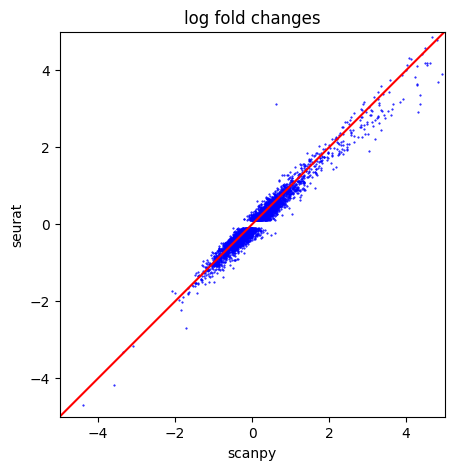

In [11]:
fig, ax = plot_diff(
    DE_table["lfc_scanpy"],
    DE_table["lfc_seurat"],
    title="log fold changes",
    xlabel="scanpy",
    ylabel="seurat",
    axis_range=5
)
plt.show()

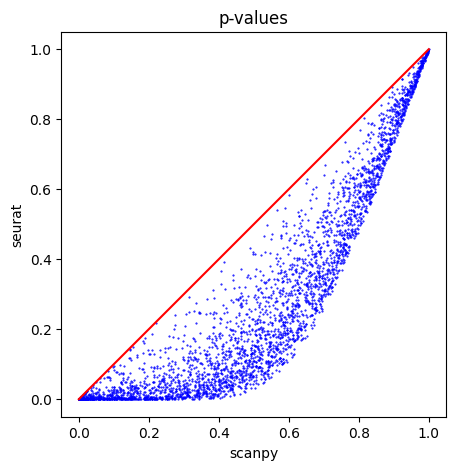

In [12]:
fig, ax = plot_diff(
    DE_table["pval_scanpy"],
    DE_table["pval_seurat"],
    title="p-values",
    xlabel="scanpy",
    ylabel="seurat"
)
plt.show()

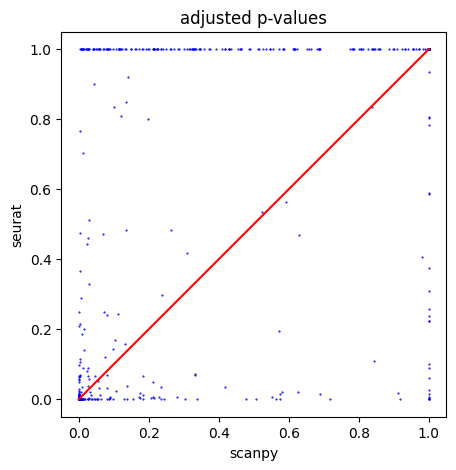

In [13]:
fig, ax = plot_diff(
    DE_table["pval_adj_scanpy"],
    DE_table["pval_adj_seurat"],
    title="adjusted p-values",
    xlabel="scanpy",
    ylabel="seurat"
)
plt.show()